In [ ]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [23]:
import gzip
def print_negative_events(lhe_path, max_events=3):
    """
    Parses an LHE file and prints the full XML block of the first `max_events`
    that contain a negative nominal weight.
    """
    print(f"Scanning {lhe_path} for negative weight events...\n")

    # Handle both compressed and uncompressed files
    open_func = gzip.open if lhe_path.endswith('.gz') else open

    inside_event = False
    event_buffer = []
    negative_count = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            # Start buffering when we hit an event tag
            if "<event>" in line:
                inside_event = True
                event_buffer = [line]
                is_negative = False
                continue

            if inside_event:
                event_buffer.append(line)

                # The line immediately after <event> contains the general event info
                if len(event_buffer) == 2:
                    parts = line.split()
                    if len(parts) >= 3:
                        # The 3rd column is XWGTUP (the nominal weight)
                        weight = float(parts[2])
                        if weight < 0:
                            is_negative = True

                # Stop buffering and print when we hit the closing tag
                if "</event>" in line:
                    inside_event = False

                    if is_negative:
                        negative_count += 1
                        print(f"==================================================")
                        print(f" FOUND NEGATIVE EVENT #{negative_count} | Weight: {weight}")
                        print(f"==================================================")
                        print("".join(event_buffer))

                        if negative_count >= max_events:
                            print(f"\n[Stopped after finding {max_events} events]")
                            return

    if negative_count == 0:
        print("No negative events found in this file.")
    else:
        print(f"\n[Finished scanning file. Found {negative_count} negative events total.]")

# ==========================================
# Execution
# ==========================================
# Replace with your actual file path
#file_path = './drive/MyDrive/FullSamples_LHEs/Scalar/events.lhe.gz'
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

# Change max_events to see more or fewer blocks
print_negative_events(file_path, max_events=4)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for negative weight events...

 FOUND NEGATIVE EVENT #1 | Weight: -8.6508469e-11
<event>
 4      0 -8.6508469e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
        2 -1    0    0  599  599 +0.0000000000e+00 +0.0000000000e+00 +2.8376793400e+03 2.8376793400e+03 0.0000000000e+00 0.0000e+00 9.0000e+00
       -2 -1    0    0  599  599 +0.0000000000e+00 +0.0000000000e+00 -2.6215214113e+03 2.6215214113e+03 0.0000000000e+00 0.0000e+00 9.0000e+00
        6  1    0    0  599  599 +1.2016793886e+02 -6.0378485406e+02 +2.7616607246e+03 2.8346693707e+03 1.7200000000e+02 0.0000e+00 9.0000e+00
       -6  1    0    0  599  599 -1.2016793886e+02 +6.0378485406e+02 -2.5455027959e+03 2.6245313806e+03 1.7200000000e+02 0.0000e+00 9.0000e+00
#aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.20000000D+01
<rwgt>
<wgt id='1001'> -8.6

In [26]:
import gzip

def print_negative_events(lhe_path, max_events=3, threshold=1e-6):
    """
    Parses an LHE file and prints the full XML block of the first `max_events`
    that contain a negative nominal weight with an absolute value >= `threshold`.
    """
    print(f"Scanning {lhe_path} for negative weight events with |W| >= {threshold}...\n")

    # Handle both compressed and uncompressed files
    open_func = gzip.open if lhe_path.endswith('.gz') else open

    inside_event = False
    event_buffer = []
    negative_count = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            # Start buffering when we hit an event tag
            if "<event>" in line:
                inside_event = True
                event_buffer = [line]
                is_target_negative = False
                continue

            if inside_event:
                event_buffer.append(line)

                # The line immediately after <event> contains the general event info
                if len(event_buffer) == 2:
                    parts = line.split()
                    if len(parts) >= 3:
                        # The 3rd column is XWGTUP (the nominal weight)
                        weight = float(parts[2])
                        
                        # Check if negative AND magnitude is large enough
                        if weight < 0 and abs(weight) >= threshold:
                            is_target_negative = True

                # Stop buffering and print when we hit the closing tag
                if "</event>" in line:
                    inside_event = False

                    if is_target_negative:
                        negative_count += 1
                        print(f"==================================================")
                        print(f" FOUND TARGET NEGATIVE EVENT #{negative_count} | Weight: {weight:.4e}")
                        print(f"==================================================")
                        print("".join(event_buffer))

                        if negative_count >= max_events:
                            print(f"\n[Stopped after finding {max_events} target events]")
                            return

    if negative_count == 0:
        print(f"No negative events with |W| >= {threshold} found in this file.")
    else:
        print(f"\n[Finished scanning file. Found {negative_count} target negative events total.]")

# ==========================================
# Execution
# ==========================================
# Replace with your actual file path
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

# Set threshold to 1e-5 to catch weights of order 10^-5, 10^-4, etc.
print_negative_events(file_path, max_events=4, threshold=1e-6)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for negative weight events with |W| >= 1e-06...

 FOUND TARGET NEGATIVE EVENT #1 | Weight: -3.2669e-06
<event>
 4      0 -3.2669403e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00
       21 -1    0    0  599  599 +0.0000000000e+00 +0.0000000000e+00 +3.6294728989e+02 3.6294728989e+02 0.0000000000e+00 0.0000e+00 9.0000e+00
       21 -1    0    0  599  599 +0.0000000000e+00 +0.0000000000e+00 -1.2884077770e+02 1.2884077770e+02 0.0000000000e+00 0.0000e+00 9.0000e+00
        6  1    0    0  599  599 +3.9673154576e+01 -1.2432190589e+02 +1.3091077888e+02 2.5249064835e+02 1.7200000000e+02 0.0000e+00 9.0000e+00
       -6  1    0    0  599  599 -3.9673154576e+01 +1.2432190589e+02 +1.0319573332e+02 2.3929741924e+02 1.7200000000e+02 0.0000e+00 9.0000e+00
#aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.30000000D+01
<rwgt

In [21]:
import gzip

def inspect_amcatnlo_tags(lhe_path, max_events=5):
    """
    Scans an LHE file and extracts the #aMCatNLO tag specifically
    for events that have a negative nominal weight.
    """
    print(f"Scanning {lhe_path} for negative event tags...\n")
    open_func = gzip.open if lhe_path.endswith('.gz') else open

    events_found = 0

    with open_func(lhe_path, 'rt') as f:
        inside_event = False
        current_weight = 0.0

        for line in f:
            if "<event>" in line:
                inside_event = True
                # The line immediately following <event> contains the weight
                weight_line = next(f).split()
                current_weight = float(weight_line[2])
                continue

            # If we are inside an event and find the tag
            if inside_event and line.startswith("#aMCatNLO"):
                if current_weight < 0:
                    print(f"Weight: {current_weight}")
                    print(f"Tag:    {line.strip()}")
                    print("-" * 60)
                    events_found += 1

                # We found the tag, we can stop tracking this specific event
                inside_event = False

            if events_found >= max_events:
                break

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'
inspect_amcatnlo_tags(file_path, max_events=5)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for negative event tags...

Weight: -8.6508469e-11
Tag:    #aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.20000000D+01
------------------------------------------------------------
Weight: -6.7467586e-11
Tag:    #aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.20000000D+01
------------------------------------------------------------
Weight: -4.035495e-16
Tag:    #aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.30000000D+01
------------------------------------------------------------
Weight: -1.6288426e-16
Tag:    #aMCatNLO 0  0  0  0  0 0.00000000D+00 0.00000000D+00   9  5  0 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.00000000D+00 0.30000000D+01
-------

Scanning ./../../UnfoldingBSMttbar/processFolders/VLF/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1300_1200/events.lhe.gz for kinematic weight analysis...

Scan complete. Processed 2014066 events.
  -> Positive weights: 2011433
  -> Negative weights: 2633


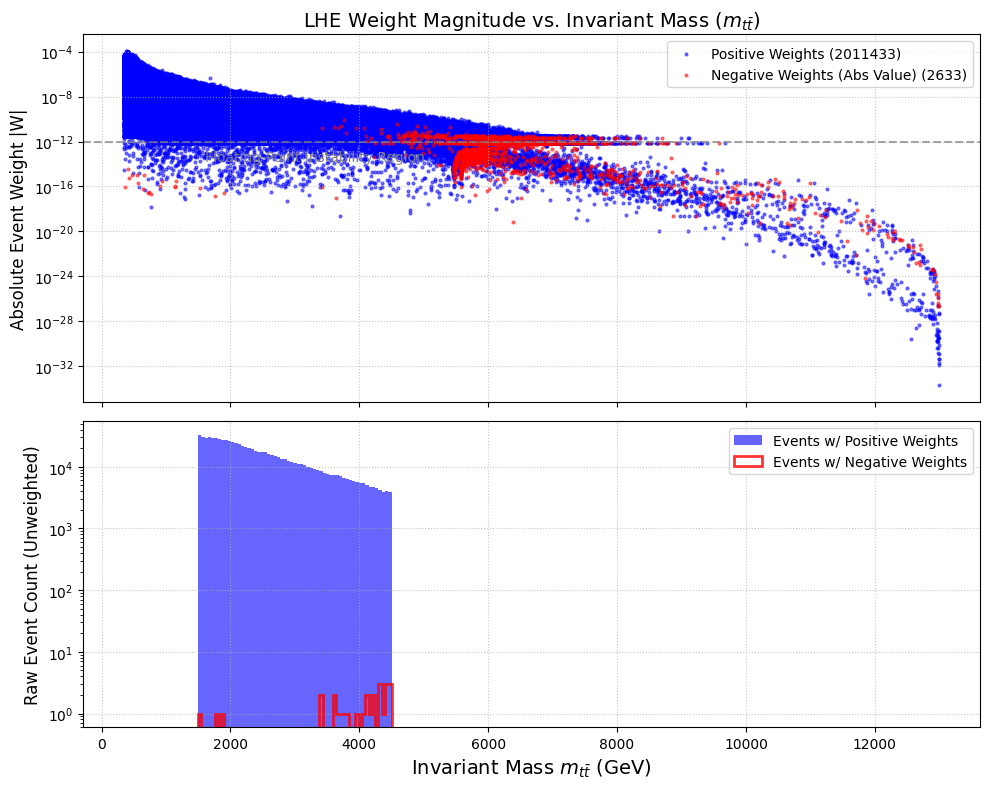

In [11]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

def analyze_lhe_weights_mtt(lhe_path, max_events=None):
    """
    Parses an LHE file, extracts the event weights, and calculates 
    the invariant mass (m_tt) of the top/anti-top pair.
    """
    print(f"Scanning {lhe_path} for kinematic weight analysis...")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    mtt_pos, w_pos = [], []
    mtt_neg, w_neg = [], []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    
    top_p4 = None
    atop_p4 = None
    
    events_processed = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            line = line.strip()
            
            if "<event>" in line:
                inside_event = True
                event_line_count = 0
                top_p4 = None
                atop_p4 = None
                continue
                
            if inside_event:
                event_line_count += 1
                parts = line.split()
                
                # The first line inside <event> contains the weight
                if event_line_count == 1:
                    if len(parts) >= 3:
                        current_weight = float(parts[2])
                    continue
                
                # Stop parsing this event when we hit the closing tag
                if "</event>" in line:
                    inside_event = False
                    
                    # Calculate invariant mass if we found both tops
                    if top_p4 is not None and atop_p4 is not None:
                        # 4-momentum: (px, py, pz, E)
                        px = top_p4[0] + atop_p4[0]
                        py = top_p4[1] + atop_p4[1]
                        pz = top_p4[2] + atop_p4[2]
                        E  = top_p4[3] + atop_p4[3]
                        
                        mtt = np.sqrt(max(0, E**2 - px**2 - py**2 - pz**2))
                        
                        # Sort by weight sign
                        if current_weight >= 0:
                            mtt_pos.append(mtt)
                            w_pos.append(current_weight)
                        else:
                            mtt_neg.append(mtt)
                            w_neg.append(current_weight)
                            
                    events_processed += 1
                    if max_events and events_processed >= max_events:
                        break
                    
                    # Print progress
                    #if events_processed % 10000 == 0:
                        #print(f"Processed {events_processed} events...")
                    continue
                
                # Parse particle lines looking for tops (PDG ID = 6) and anti-tops (-6)
                if len(parts) >= 10:
                    try:
                        pdg_id = int(parts[0])
                        # We grab the 4-momentum: px, py, pz, E (columns 6, 7, 8, 9 in 0-indexed split)
                        if pdg_id == 6:
                            top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        elif pdg_id == -6:
                            atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                    except ValueError:
                        pass # Header/comment lines inside block if any

    print(f"\nScan complete. Processed {events_processed} events.")
    print(f"  -> Positive weights: {len(w_pos)}")
    print(f"  -> Negative weights: {len(w_neg)}")
    
    return np.array(mtt_pos), np.array(w_pos), np.array(mtt_neg), np.array(w_neg)

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Generates a 2-panel plot diagnosing the magnitude and phase space 
    of the negative weights.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
    
    # ---------------------------------------------------------
    # TOP PANEL: Magnitude Check (Scatter)
    # ---------------------------------------------------------
    # Plot positive weights
    ax_mag.scatter(mtt_pos, w_pos, color='blue', alpha=0.5, s=4, label=f'Positive Weights ({len(w_pos)})')
    
    # Plot absolute value of negative weights
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, label=f'Negative Weights (Abs Value) ({len(w_neg)})')
        
    # FIX: Added 'r' to the strings so \b in \bar isn't read as a backspace
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log') # Log scale is crucial here!
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    
    # FIX: Removed the invalid 'markersize' argument
    ax_mag.legend(loc='upper right')
    
    # Draw reference line for floating point precision boundary (approx 1e-12)
    ax_mag.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    ax_mag.text(1600, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # ---------------------------------------------------------
    # BOTTOM PANEL: Phase Space Check (Histogram)
    # ---------------------------------------------------------
    bins = np.linspace(1500, 4500, 60)
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, label='Events w/ Positive Weights')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, label='Events w/ Negative Weights', histtype='step', linewidth=2)

    # FIX: Added 'r' here as well
    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count (Unweighted)", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('lhe_weight_diagnostics.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/VLF/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1300_1200/events.lhe.gz'

# Run parser
mtt_pos, w_pos, mtt_neg, w_neg = analyze_lhe_weights_mtt(file_path, max_events=None)

# Plot diagnostics
plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for kinematic weight analysis...

Scan complete. Processed 2623444 events.
  -> Positive weights: 2621990
  -> Negative weights: 1454


/tmp/ipykernel_10054/901907792.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


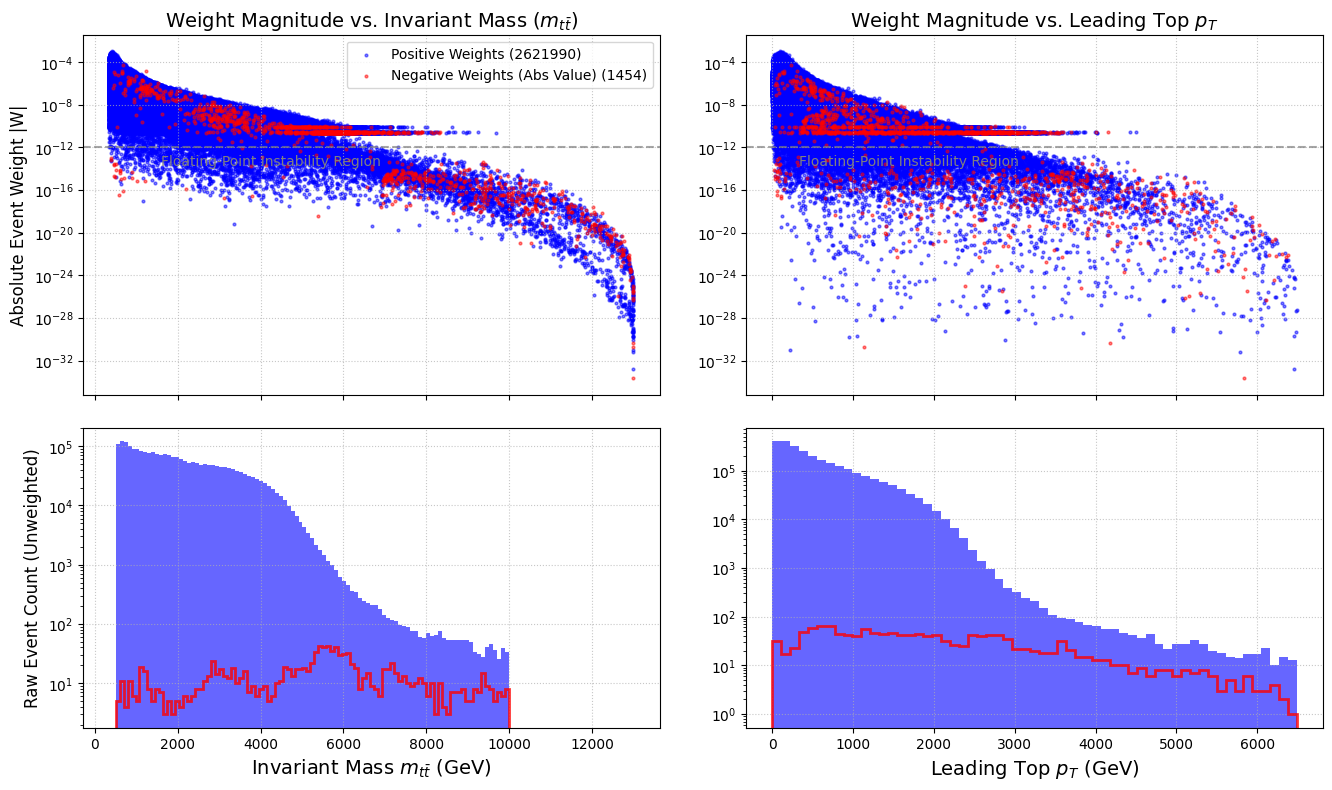

 CROSS-SECTION IMPACT ANALYSIS
Total Positive Yield: 8.404871e+00
Total Negative Yield (Abs): 1.834331e-04
--------------------------------------------------
Fractional Impact: 2.182462e-05
Percentage Impact: 0.002182462108%
CONCLUSION: Negative weights are large enough to be physical.


In [36]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

def analyze_lhe_weights(lhe_path, max_events=None):
    """
    Parses an LHE file, extracts the event weights, and calculates 
    the invariant mass (m_tt) and leading top p_T.
    """
    print(f"Scanning {lhe_path} for kinematic weight analysis...")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    mtt_pos, pt_pos, w_pos = [], [], []
    mtt_neg, pt_neg, w_neg = [], [], []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    
    top_p4 = None
    atop_p4 = None
    
    events_processed = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            line = line.strip()
            
            if "<event>" in line:
                inside_event = True
                event_line_count = 0
                top_p4 = None
                atop_p4 = None
                continue
                
            if inside_event:
                event_line_count += 1
                parts = line.split()
                
                # The first line inside <event> contains the weight
                if event_line_count == 1:
                    if len(parts) >= 3:
                        current_weight = float(parts[2])
                    continue
                
                # Stop parsing this event when we hit the closing tag
                if "</event>" in line:
                    inside_event = False
                    
                    # Calculate kinematics if we found both tops
                    if top_p4 is not None and atop_p4 is not None:
                        # 4-momentum: (px, py, pz, E)
                        px = top_p4[0] + atop_p4[0]
                        py = top_p4[1] + atop_p4[1]
                        pz = top_p4[2] + atop_p4[2]
                        E  = top_p4[3] + atop_p4[3]
                        
                        mtt = np.sqrt(max(0, E**2 - px**2 - py**2 - pz**2))
                        
                        # Calculate transverse momentum for both, pick the leading one
                        pt_top = np.sqrt(top_p4[0]**2 + top_p4[1]**2)
                        pt_atop = np.sqrt(atop_p4[0]**2 + atop_p4[1]**2)
                        leading_pt = max(pt_top, pt_atop)
                        
                        # Sort by weight sign
                        if current_weight >= 0:
                            mtt_pos.append(mtt)
                            pt_pos.append(leading_pt)
                            w_pos.append(current_weight)
                        else:
                            mtt_neg.append(mtt)
                            pt_neg.append(leading_pt)
                            w_neg.append(current_weight)
                            
                    events_processed += 1
                    if max_events and events_processed >= max_events:
                        break
                    continue
                
                # Parse particle lines looking for tops (PDG ID = 6) and anti-tops (-6)
                if len(parts) >= 10:
                    try:
                        pdg_id = int(parts[0])
                        # We grab the 4-momentum: px, py, pz, E (columns 6, 7, 8, 9 in 0-indexed split)
                        if pdg_id == 6:
                            top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        elif pdg_id == -6:
                            atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                    except ValueError:
                        pass # Header/comment lines inside block if any

    print(f"\nScan complete. Processed {events_processed} events.")
    print(f"  -> Positive weights: {len(w_pos)}")
    print(f"  -> Negative weights: {len(w_neg)}")
    
    return (np.array(mtt_pos), np.array(pt_pos), np.array(w_pos), 
            np.array(mtt_neg), np.array(pt_neg), np.array(w_neg))

def plot_weight_diagnostics(mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg):
    """
    Generates a 2x2 plot diagnosing the magnitude and phase space 
    of the negative weights for both m_tt and leading p_T.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col', gridspec_kw={'height_ratios': [1.2, 1], 'wspace': 0.15, 'hspace': 0.1})
    
    ax_mag_mtt, ax_mag_pt = axes[0]
    ax_hist_mtt, ax_hist_pt = axes[1]
    
    # =========================================================
    # COLUMN 1: INVARIANT MASS (m_tt)
    # =========================================================
    # Magnitude Check
    ax_mag_mtt.scatter(mtt_pos, w_pos, color='blue', alpha=0.5, s=4, label=f'Positive Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag_mtt.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, label=f'Negative Weights (Abs Value) ({len(w_neg)})')
        
    ax_mag_mtt.set_title(r"Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag_mtt.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag_mtt.set_yscale('log')
    ax_mag_mtt.grid(True, linestyle=':', alpha=0.7)
    ax_mag_mtt.legend(loc='upper right')
    ax_mag_mtt.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    ax_mag_mtt.text(1600, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # Phase Space Histogram
    mtt_bins = np.linspace(500, 10000, 100)
    ax_hist_mtt.hist(mtt_pos, bins=mtt_bins, color='blue', alpha=0.6, label='Events w/ Positive Weights')
    if len(w_neg) > 0:
        ax_hist_mtt.hist(mtt_neg, bins=mtt_bins, color='red', alpha=0.8, label='Events w/ Negative Weights', histtype='step', linewidth=2)

    ax_hist_mtt.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist_mtt.set_ylabel("Raw Event Count (Unweighted)", fontsize=12)
    ax_hist_mtt.set_yscale('log')
    ax_hist_mtt.grid(True, linestyle=':', alpha=0.7)

    # =========================================================
    # COLUMN 2: LEADING TOP p_T
    # =========================================================
    # Magnitude Check
    ax_mag_pt.scatter(pt_pos, w_pos, color='blue', alpha=0.5, s=4)
    if len(w_neg) > 0:
        ax_mag_pt.scatter(pt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4)
        
    ax_mag_pt.set_title(r"Weight Magnitude vs. Leading Top $p_T$", fontsize=14)
    ax_mag_pt.set_yscale('log')
    ax_mag_pt.grid(True, linestyle=':', alpha=0.7)
    ax_mag_pt.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    ax_mag_pt.text(max(pt_pos)*0.05, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # Phase Space Histogram
    # Dynamically scale the p_T bins based on the data range
    all_pts = np.concatenate([pt_pos, pt_neg]) if len(w_neg) > 0 else pt_pos
    pt_bins = np.linspace(min(all_pts), max(all_pts), 60)
    
    ax_hist_pt.hist(pt_pos, bins=pt_bins, color='blue', alpha=0.6)
    if len(w_neg) > 0:
        ax_hist_pt.hist(pt_neg, bins=pt_bins, color='red', alpha=0.8, histtype='step', linewidth=2)

    ax_hist_pt.set_xlabel(r"Leading Top $p_T$ (GeV)", fontsize=14)
    ax_hist_pt.set_yscale('log')
    ax_hist_pt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('lhe_weight_diagnostics_2x2.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/VLF/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1300_1200/events.lhe.gz'
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1000_900/events.lhe.gz'
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

# Run parser
mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg = analyze_lhe_weights(file_path, max_events=None)

# Plot diagnostics
plot_weight_diagnostics(mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg)

import numpy as np

# Calculate total cross-section (sum of weights)
yield_pos = np.sum(w_pos)
yield_neg_abs = np.sum(np.abs(w_neg))

# Calculate the fractional impact
fractional_impact = yield_neg_abs / yield_pos
percentage_impact = fractional_impact * 100

print("==================================================")
print(" CROSS-SECTION IMPACT ANALYSIS")
print("==================================================")
print(f"Total Positive Yield: {yield_pos:.6e}")
print(f"Total Negative Yield (Abs): {yield_neg_abs:.6e}")
print("--------------------------------------------------")
print(f"Fractional Impact: {fractional_impact:.6e}")
print(f"Percentage Impact: {percentage_impact:.12f}%")
print("==================================================")

if percentage_impact < 1e-5:
    print("CONCLUSION: 100% CERTAIN. Negative weights are numerical noise.")
    print("They are millions of times too small to be physical.")
else:
    print("CONCLUSION: Negative weights are large enough to be physical.")

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for FKS Subtraction mirroring...
Processed 1666802 events.
Matching FKS counterterm pairs by kinematics...
Found 73 perfectly matched FKS pairs out of 806 negative events.


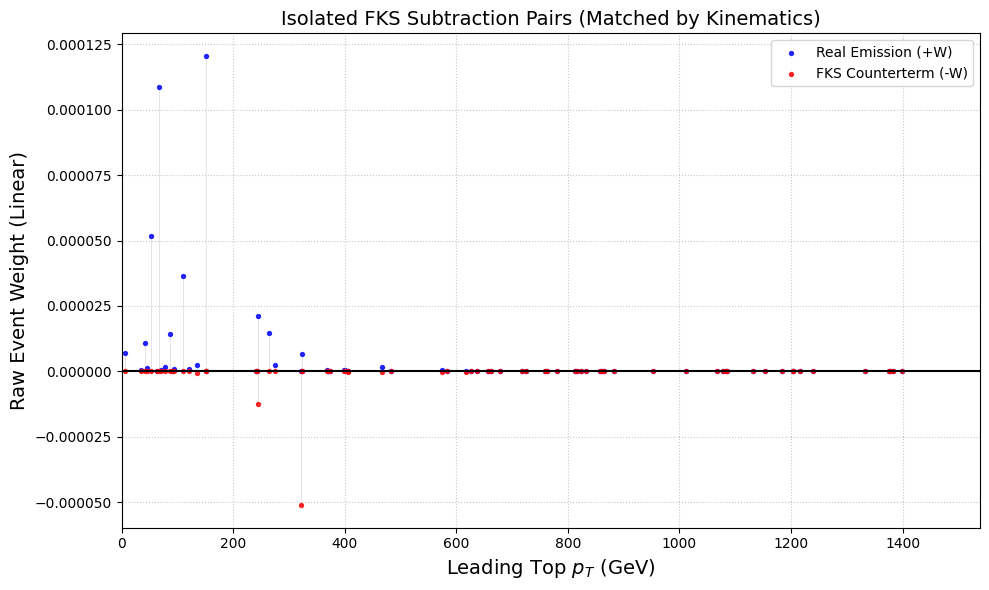

In [32]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def analyze_signed_weights(lhe_path, max_events=None):
    print(f"Scanning {lhe_path} for FKS Subtraction mirroring...")
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    pt_leading = []
    weights = []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    top_p4, atop_p4 = None, None
    events_processed = 0

    try:
        with open_func(lhe_path, 'rt') as f:
            for line in f:
                line = line.strip()
                
                if "<event>" in line:
                    inside_event = True
                    event_line_count = 0
                    top_p4, atop_p4 = None, None
                    continue
                    
                if inside_event:
                    event_line_count += 1
                    parts = line.split()
                    
                    if event_line_count == 1:
                        if len(parts) >= 3:
                            current_weight = float(parts[2])
                        continue
                    
                    if "</event>" in line:
                        inside_event = False
                        if top_p4 is not None and atop_p4 is not None:
                            pt_top = np.sqrt(top_p4[0]**2 + top_p4[1]**2)
                            pt_atop = np.sqrt(atop_p4[0]**2 + atop_p4[1]**2)
                            
                            pt_leading.append(max(pt_top, pt_atop))
                            weights.append(current_weight)
                                
                        events_processed += 1
                        if max_events and events_processed >= max_events:
                            break
                        continue
                    
                    if len(parts) >= 10:
                        try:
                            pdg_id = int(parts[0])
                            if pdg_id == 6:
                                top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                            elif pdg_id == -6:
                                atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        except ValueError:
                            pass
                            
    except EOFError:
        print(f"\n[WARNING] Reached a corrupted section of the file (EOFError)!")
        print(f"The file {lhe_path} is truncated.")
        print(f"Salvaging the {events_processed} events that were successfully read prior to the crash...\n")

    print(f"Processed {events_processed} events.")
    return np.array(pt_leading), np.array(weights)

def extract_fks_pairs(pt, w, tolerance=1e-4):
    """
    Finds exact kinematic matches between positive and negative weight events.
    """
    print("Matching FKS counterterm pairs by kinematics...")
    mask_pos = w >= 0
    mask_neg = w < 0
    
    pt_pos = pt[mask_pos]
    w_pos = w[mask_pos]
    
    pt_neg = pt[mask_neg]
    w_neg = w[mask_neg]
    
    # Sort positive events for fast binary searching
    sort_idx = np.argsort(pt_pos)
    pt_pos_sorted = pt_pos[sort_idx]
    w_pos_sorted = w_pos[sort_idx]
    
    paired_pt = []
    paired_w_pos = []
    paired_w_neg = []
    
    # Track used positive indices to avoid double-matching the same event
    used_pos_indices = set()
    
    for i in range(len(pt_neg)):
        p_n = pt_neg[i]
        w_n = w_neg[i]
        
        # Find the closest positive p_T index
        idx = np.searchsorted(pt_pos_sorted, p_n)
        
        best_idx = -1
        min_diff = float('inf')
        
        # Check the closest neighbors (handles exact matches and slight rounding differences)
        for check_idx in [idx - 1, idx, idx + 1]:
            if 0 <= check_idx < len(pt_pos_sorted):
                diff = abs(pt_pos_sorted[check_idx] - p_n)
                if diff < min_diff and check_idx not in used_pos_indices:
                    min_diff = diff
                    best_idx = check_idx
                    
        # If the kinematic match is closer than our tolerance, it's an FKS pair
        if min_diff < tolerance and best_idx != -1:
            paired_pt.append(p_n)
            paired_w_neg.append(w_n)
            paired_w_pos.append(w_pos_sorted[best_idx])
            used_pos_indices.add(best_idx)
            
    print(f"Found {len(paired_pt)} perfectly matched FKS pairs out of {len(pt_neg)} negative events.")
    return np.array(paired_pt), np.array(paired_w_pos), np.array(paired_w_neg)

def plot_fks_isolated_pairs(pt_pairs, w_pos, w_neg):
    """
    Plots only the verified pairs, drawing a line between them to show the cancellation.
    """
    if len(pt_pairs) == 0:
        print("No pairs found to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Draw vertical connecting lines between pairs to prove they share the exact p_T
    segments = [[(p, wp), (p, wn)] for p, wp, wn in zip(pt_pairs, w_pos, w_neg)]
    lc = LineCollection(segments, colors='gray', alpha=0.3, linewidths=0.5, zorder=0)
    ax.add_collection(lc)
    
    # Plot the isolated pairs
    ax.scatter(pt_pairs, w_pos, color='blue', alpha=0.8, s=8, label='Real Emission (+W)')
    ax.scatter(pt_pairs, w_neg, color='red', alpha=0.8, s=8, label='FKS Counterterm (-W)')
    
    ax.set_title("Isolated FKS Subtraction Pairs (Matched by Kinematics)", fontsize=14)
    ax.set_xlabel(r"Leading Top $p_T$ (GeV)", fontsize=14)
    ax.set_ylabel("Raw Event Weight (Linear)", fontsize=14)
    
    # Draw zero reference line
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-')
    
    # Auto-scale x-axis to the actual data range of the pairs
    ax.set_xlim(0, max(pt_pairs) * 1.1) 
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('fks_isolated_pairs.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

# 1. Parse the file
pt, w = analyze_signed_weights(file_path)

# 2. Extract only the exact FKS pairs
pt_pairs, w_pos_pairs, w_neg_pairs = extract_fks_pairs(pt, w, tolerance=1e-4)

# 3. Plot only the pairs
plot_fks_isolated_pairs(pt_pairs, w_pos_pairs, w_neg_pairs)

In [33]:
# Sum everything, don't look for pairs
total_pos = np.sum(w[w >= 0])
total_neg = np.sum(w[w < 0])

print(f"Total Positive Weight: {total_pos:.6e}")
print(f"Total Negative Weight: {total_neg:.6e}")
print(f"Net Cross-Section:    {total_pos + total_neg:.6e}")

Total Positive Weight: 8.407493e+00
Total Negative Weight: -1.359992e-04
Net Cross-Section:    8.407357e+00
